# Grassroots Tournament Scenes: Counter-Strike vs. Dota 2

**Purpose:** extends `research/esports_lifecycle_and_maturity/brief.md`'s "has CS finished
growing" question down to the grassroots (community) tier, and makes it
comparative against Dota 2 for the first time — closing out brief §10 item 1
(re-run once `collectors/liquipedia_grassroots.py` finished) with the real
crawled data, replacing the brief's own §9/§15 title-year proxy (which
excluded 44-47% of pages with no parseable year in the title).

`collectors/liquipedia_grassroots.py` crawls Counter-Strike's B-Tier/C-Tier
categories and Dota 2's Tier 3/Tier 4 categories on Liquipedia — the
community/regional tournament tiers below this project's tier-1/2 ("esports")
scope. It finished its main run 2026-09-10, plus a small follow-up re-run the
same day that recovered 7 transiently-failed pages and picked up pages newly
added to the categories since the first pass.

Every dimension below is shown with its own coverage caveat stated up front,
not left to a footnote — same convention as `cs_growth_trajectory.ipynb` and
`dota2_growth_trajectory.ipynb`.

In [1]:
# Imports and repo path setup -- same pattern as cs_growth_trajectory.ipynb.
import csv
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Static PNG output, not the interactive JSON widget -- same reasoning
# title_geography_maps.ipynb already uses (portable: GitHub preview, a
# downloaded file, no live-kernel dependency).
pio.renderers.default = "png"


from etl.db import get_connection

conn = get_connection()
plt.rcParams["figure.dpi"] = 110

# Partition logic, per title -- NOT the same rule for both, and that's worth
# stating explicitly rather than hiding behind one shared constant.
#
# counter_strike: collectors/liquipedia.py's tier-1/2 crawl only ever queries
# the "S-Tier Tournaments"/"A-Tier Tournaments" categories on this wiki (its
# own TIER_CONVENTIONS). collectors/liquipedia_grassroots.py only ever queries
# "B-Tier Tournaments"/"C-Tier Tournaments". So "not S-Tier and not A-Tier" is
# a reliable partition by DISCOVERY PATH, even though some grassroots pages'
# own raw tier field is messy (a few report '2'/'3'/'4' or case variants like
# 'c-Tier' instead of the clean 'B-Tier'/'C-Tier' label -- a real Liquipedia
# data-quality inconsistency, not a bug in this project's crawler).
CS_GRASSROOTS = "tier NOT IN ('S-Tier','A-Tier')"
CS_TIER12 = "tier IN ('S-Tier','A-Tier')"

# dota2: the dota2 wiki uses a clean, purely numeric tier convention -- no
# such ambiguity, checked directly (only '1','2','3','4' appear at all).
DOTA2_GRASSROOTS = "tier IN ('3','4')"
DOTA2_TIER12 = "tier IN ('1','2')"

TITLES = [
    ("counter_strike", CS_GRASSROOTS, "#ff7f0e", "Counter-Strike"),
    ("dota2", DOTA2_GRASSROOTS, "#1f77b4", "Dota 2"),
]

## 1. Data coverage and partition method — stated explicitly before anything else

Brief §4's own standing rule applies here too: a chart that quietly starts
from partial data looks the same as one built on complete data unless the
gap is labeled. Checking every field's real coverage before charting any of
them.

In [2]:
rows = []
for title_id, filt, _, label in TITLES:
    total = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt}", conn, params=(title_id,)).iloc[0]["n"]
    with_date = pd.read_sql_query(
        f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND start_date GLOB '[0-9][0-9][0-9][0-9]-*'",
        conn, params=(title_id,)).iloc[0]["n"]
    with_region = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND region IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    with_country = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND country IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    with_prize = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND prize_pool IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    with_prize_usd = pd.read_sql_query(
        f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND prize_pool IS NOT NULL AND (currency='USD' OR currency IS NULL)",
        conn, params=(title_id,)).iloc[0]["n"]
    with_teams = pd.read_sql_query(f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} AND team_number IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    rows.append({
        "title": label, "total_pages": total,
        "start_date_parseable": f"{with_date}/{total} ({with_date/total:.0%})",
        "region_populated": f"{with_region}/{total} ({with_region/total:.0%})",
        "country_populated": f"{with_country}/{total} ({with_country/total:.0%})",
        "prize_pool_populated": f"{with_prize}/{total} ({with_prize/total:.0%})",
        "prize_pool_usd_or_null_currency": f"{with_prize_usd}/{with_prize} ({with_prize_usd/with_prize:.0%} of populated)",
        "team_number_populated": f"{with_teams}/{total} ({with_teams/total:.0%})",
    })
coverage_df = pd.DataFrame(rows).set_index("title").T
print(coverage_df.to_string())

title                                           Counter-Strike                        Dota 2
total_pages                                              18144                          3027
start_date_parseable                         12676/18144 (70%)               2417/3027 (80%)
region_populated                              8350/18144 (46%)                986/3027 (33%)
country_populated                           18144/18144 (100%)               2914/3027 (96%)
prize_pool_populated                         10718/18144 (59%)               2326/3027 (77%)
prize_pool_usd_or_null_currency  9048/10718 (84% of populated)  1518/2326 (65% of populated)
team_number_populated                        16239/18144 (90%)               2891/3027 (96%)


**Read**: both titles' grassroots scenes are large (18,144 Counter-Strike
pages, 3,027 Dota 2 pages) and have real, usable `start_date` coverage
(69.6%/79.8%) — a genuine improvement over the brief's old ~53-56%-covered
title-year proxy, since this is each page's own parsed `Infobox league`
field, not a text-mined guess. `country` is populated for nearly every row
in both titles (100%/96%), far more complete than the coarse continent-level
`region` field (46%/33%) — §4 below uses both, since they answer slightly
different questions. Prize pool data exists for most rows, but a long tail
of local currencies means only 65-84% of *populated* prize-pool rows are
USD (or unspecified, treated as USD by the same convention
`analysis/metrics.py:get_championship_windows()` uses after its own
currency-bug fix) — §5 restricts to that subset rather than mixing
currencies, same as that fix.

Every count-based chart below restricts to **2016-2025** (ten full calendar
years) for direct comparability with `cs_growth_trajectory.ipynb`'s own
window — grassroots data actually reaches back further (Counter-Strike to
2001, Dota 2 to 2012) and forward into a handful of already-announced 2027
events, both excluded here as out of window rather than incomplete/wrong.
2026 is excluded from trend lines as a partial year (this project's own
polling is still running) but shown as a separate marked point where
useful.

**A currency-contamination check, done directly rather than trusted from
the established convention**: `analysis/metrics.py:get_championship_windows()`'s
own 2026-09-09 fix treats `currency='USD' OR currency IS NULL` as the safe
USD-only subset — but that convention *assumes* a NULL currency means USD,
without verifying it for this data specifically. Checked directly below.

In [3]:
for title_id, filt, _, label in TITLES:
    null_currency_with_prize = pd.read_sql_query(
        f"SELECT count(*) AS n FROM tournaments WHERE title_id=? AND {filt} "
        f"AND currency IS NULL AND prize_pool IS NOT NULL", conn, params=(title_id,)).iloc[0]["n"]
    usd_desc = pd.read_sql_query(
        f"SELECT prize_pool FROM tournaments WHERE title_id=? AND {filt} AND currency='USD' AND prize_pool IS NOT NULL",
        conn, params=(title_id,))["prize_pool"]
    case_variants = pd.read_sql_query(
        f"SELECT DISTINCT currency FROM tournaments WHERE title_id=? AND {filt} AND currency IS NOT NULL AND lower(currency)='usd'",
        conn, params=(title_id,))["currency"].tolist()
    print(f"{label}:")
    print(f"  rows with currency IS NULL and prize_pool populated: {null_currency_with_prize} (0 = the NULL-currency fallback never actually fires here)")
    print(f"  currency='USD' spelling variants found: {case_variants}")
    print(f"  USD-tagged prize_pool: min={usd_desc.min():.0f}, median={usd_desc.median():.0f}, max={usd_desc.max():,.0f}, n={len(usd_desc)}")
    print()

Counter-Strike:
  rows with currency IS NULL and prize_pool populated: 0 (0 = the NULL-currency fallback never actually fires here)
  currency='USD' spelling variants found: ['USD']
  USD-tagged prize_pool: min=0, median=3000, max=2,500,000, n=9048

Dota 2:
  rows with currency IS NULL and prize_pool populated: 0 (0 = the NULL-currency fallback never actually fires here)
  currency='USD' spelling variants found: ['USD']
  USD-tagged prize_pool: min=50, median=3500, max=200,000, n=1518



**Clean — no contamination found.** For both titles' grassroots scope,
`currency IS NULL` never co-occurs with a populated `prize_pool` (`collectors/
liquipedia.py:parse_infobox()`'s own logic explains why: `currency` is set
to `"USD"` whenever the `prizepoolusd` field is present, or to whatever
`localcurrency` says otherwise — there's no path to a populated prize figure
with a genuinely unknown currency). So the "OR currency IS NULL" half of the
established convention is a no-op for this data, not a silent inclusion of
unverified rows — every dollar figure in §5 below is an explicitly-tagged
`'USD'` row. The USD-tagged magnitude distribution also looks internally
consistent (Counter-Strike: \$0-\$2.5M, median \$3,000; Dota 2: \$50-\$200K,
median \$3,500) — no outlier suggesting an un-converted local-currency figure
slipped through mistagged as USD. **This is a per-title-scope finding, not a
project-wide one**: the full `tournaments` table has 1,541 rows elsewhere
(other titles) where `currency IS NULL` and `prize_pool` *is* populated — a
real latent risk in `get_championship_windows()`'s general convention,
just not one that reaches Counter-Strike or Dota 2's grassroots data.

## 2. Tournament count over time — real dates, not the old title-year proxy

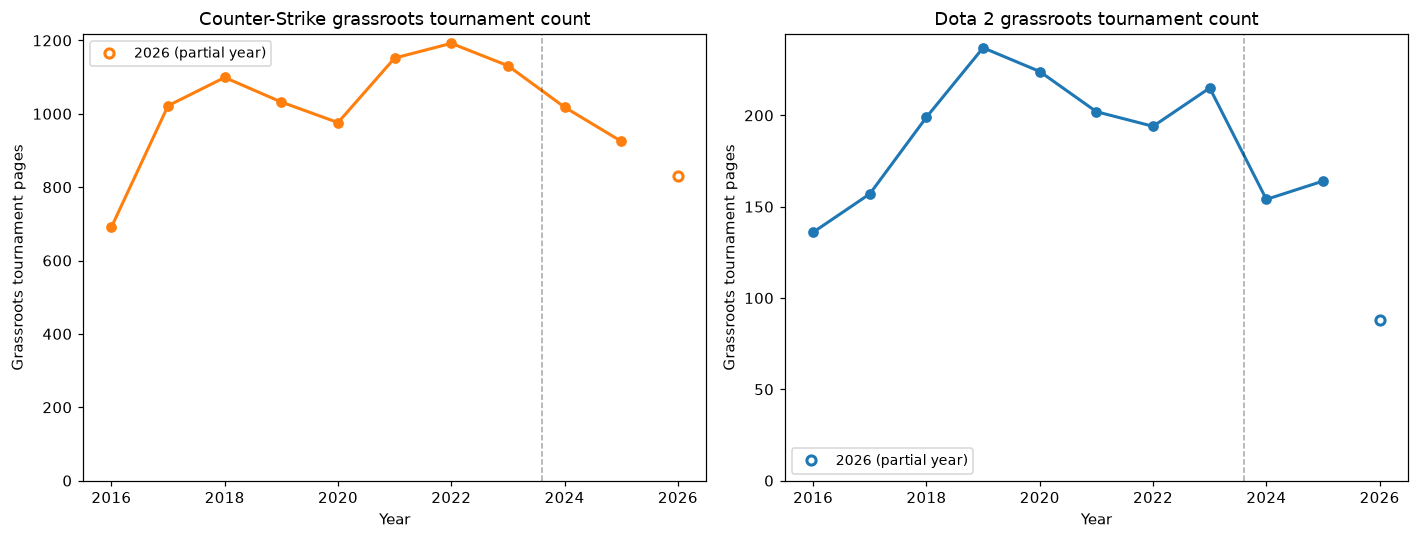

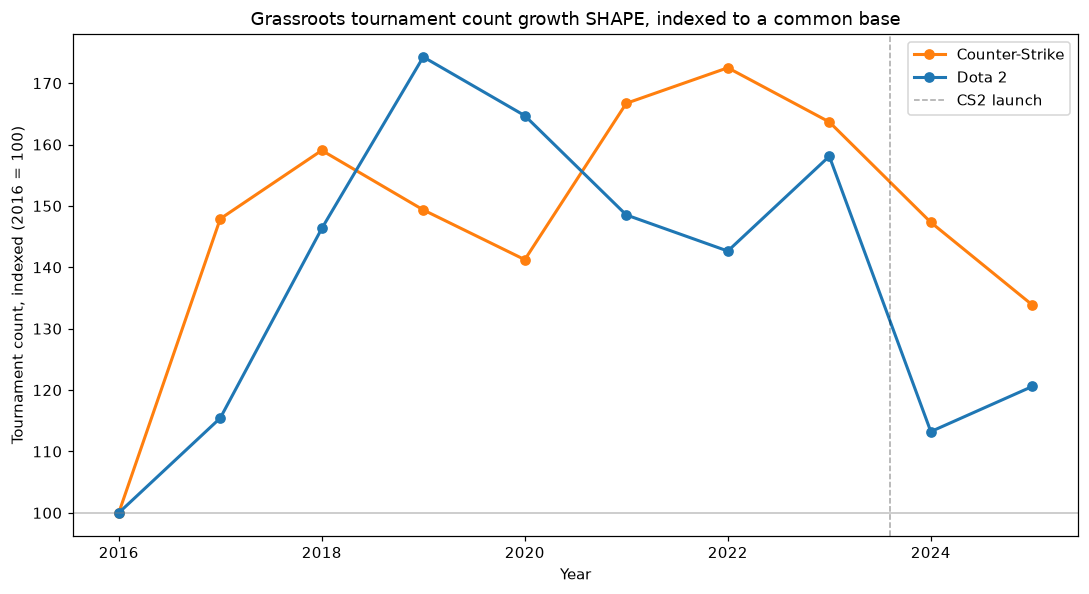


Counter-Strike:
  yr    n
2016  691
2017 1022
2018 1099
2019 1032
2020  976
2021 1152
2022 1192
2023 1131
2024 1018
2025  925
2026  831

Dota 2:
  yr   n
2016 136
2017 157
2018 199
2019 237
2020 224
2021 202
2022 194
2023 215
2024 154
2025 164
2026  88


In [4]:
def yearly_counts(title_id, filt):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, count(*) AS n FROM tournaments "
        f"WHERE title_id=? AND {filt} AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' GROUP BY yr ORDER BY yr",
        conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    return df

count_dfs = {title_id: yearly_counts(title_id, filt) for title_id, filt, _, _ in TITLES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title_id, filt, color, label) in zip(axes, TITLES):
    df = count_dfs[title_id]
    window = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]
    partial = df[df["yr"] == 2026]
    ax.plot(window["yr"], window["n"], "o-", color=color, linewidth=2)
    if not partial.empty:
        ax.plot(partial["yr"], partial["n"], "o", color=color, markerfacecolor="white", markeredgewidth=2, label="2026 (partial year)")
        ax.legend(fontsize=9)
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_xlabel("Year")
    ax.set_ylabel("Grassroots tournament pages")
    ax.set_title(f"{label} grassroots tournament count")
    ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig1_counts_raw.png", dpi=110)
plt.show()

# Indexed to 2016=100, to compare growth SHAPE independent of the ~5x scale gap.
fig, ax = plt.subplots(figsize=(10, 5.5))
for title_id, filt, color, label in TITLES:
    df = count_dfs[title_id]
    window = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)].copy()
    base = window[window["yr"] == 2016]["n"].iloc[0]
    window["idx"] = 100 * window["n"] / base
    ax.plot(window["yr"], window["idx"], "o-", color=color, linewidth=2, label=label)
ax.axhline(100, color="gray", linewidth=1, alpha=0.5)
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.35, label="CS2 launch")
ax.set_xlabel("Year")
ax.set_ylabel("Tournament count, indexed (2016 = 100)")
ax.set_title("Grassroots tournament count growth SHAPE, indexed to a common base")
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig2_counts_indexed.png", dpi=110)
plt.show()

for title_id, _, _, label in TITLES:
    df = count_dfs[title_id]
    print(f"\n{label}:")
    print(df[(df['yr']>=2016)&(df['yr']<=2026)].to_string(index=False))

**Read**: real per-page dates tell a meaningfully different story from
the brief's own old title-year proxy in places, worth correcting explicitly
rather than quietly superseding. Counter-Strike's grassroots count actually
**peaked in 2022 (1,192)**, not 2021 as the proxy suggested, after a real but
mild 2019-2020 dip (1,099 → 976, ~11%, not the "sharp" COVID drop the old
proxy implied) — then declines through 2023-2025 (1,131 → 1,018 → 925). But
**2025's 925 sits meaningfully above 2016's 691**, not "back to roughly
2016-2017 levels" as the old proxy read it — the real data supports a
narrowing-from-a-higher-peak story, not a full round-trip to the starting
point. Dota 2 peaked earlier, in 2019 (237), and by 2025 (164) is down ~31%
from that peak but still above its own 2016 level (136) — and shows no sharp
2020 dip at all, unlike Counter-Strike. Indexed together, both titles'
grassroots scenes are narrowing from a mid-cycle peak rather than growing
into 2025, but on different timelines and with different shock profiles —
consistent with, and now real evidence for, the brief's existing tier-1/2
narrowing finding, extended down to the community level for both titles for
the first time.

## 3. Team participation — a proxy, not unique teams

Same real limitation `cs_growth_trajectory.ipynb` §14 already flagged for
tier-1/2: Liquipedia's `Infobox league` stores `team_number` as a per-event
*headcount*, not team identities — there is no roster/participant-list data
anywhere in this project's schema (confirmed again during today's PRD §19
review: the player/roster connector that would enable true unique-team
counting is scoped, not built). What's shown below is total
**participant-slots** (sum of `team_number`) per year — a scale/opportunity
proxy, since the same teams reappear across many grassroots events and get
counted at every one.

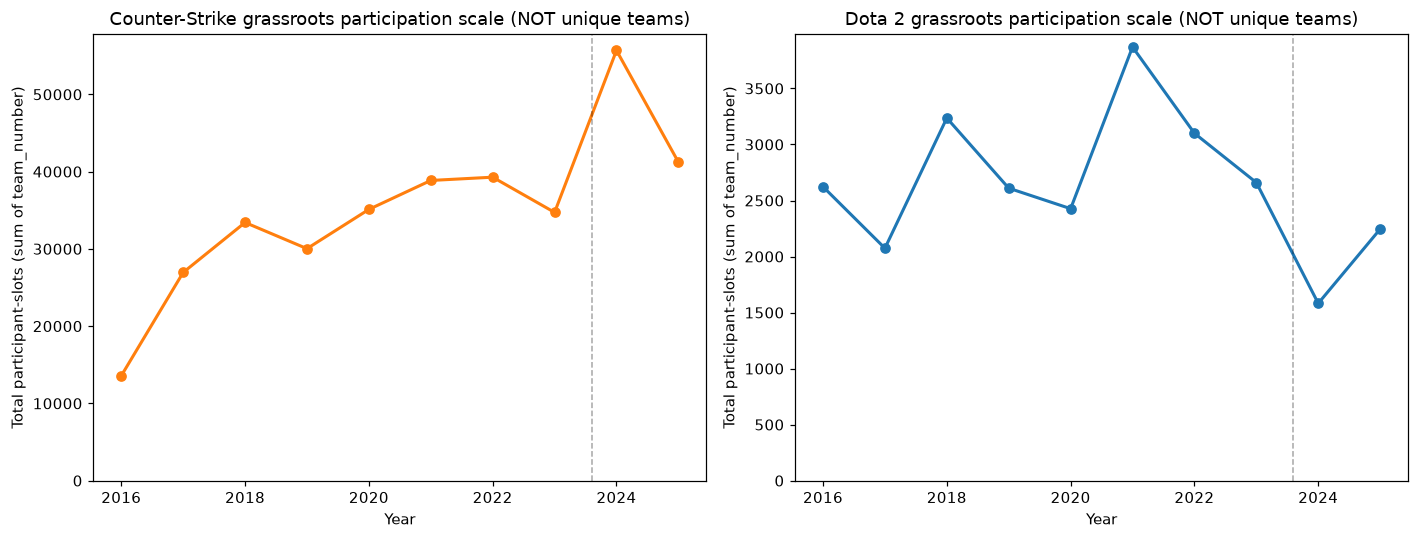


Counter-Strike (coverage = share of rows with team_number populated):
  yr  slots  coverage
2016  13571      0.81
2017  26948      0.88
2018  33415      0.91
2019  30028      0.90
2020  35110      0.89
2021  38855      0.93
2022  39279      0.92
2023  34721      0.93
2024  55686      0.95
2025  41230      0.98
2026  25593      0.94

Dota 2 (coverage = share of rows with team_number populated):
  yr  slots  coverage
2016   2623      0.96
2017   2074      0.96
2018   3236      0.95
2019   2610      0.97
2020   2427      0.99
2021   3870      1.00
2022   3100      1.00
2023   2660      1.00
2024   1582      1.00
2025   2245      0.99
2026    993      0.95


In [5]:
def yearly_slots(title_id, filt):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(team_number) AS slots, "
        f"count(team_number) AS n_with_data, count(*) AS n_total "
        f"FROM tournaments WHERE title_id=? AND {filt} "
        f"AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' GROUP BY yr ORDER BY yr",
        conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    df["coverage"] = df["n_with_data"] / df["n_total"]
    return df

slots_dfs = {title_id: yearly_slots(title_id, filt) for title_id, filt, _, _ in TITLES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title_id, filt, color, label) in zip(axes, TITLES):
    df = slots_dfs[title_id]
    window = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]
    ax.plot(window["yr"], window["slots"], "o-", color=color, linewidth=2)
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_xlabel("Year")
    ax.set_ylabel("Total participant-slots (sum of team_number)")
    ax.set_title(f"{label} grassroots participation scale (NOT unique teams)")
    ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig3_slots_raw.png", dpi=110)
plt.show()

for title_id, _, _, label in TITLES:
    df = slots_dfs[title_id]
    print(f"\n{label} (coverage = share of rows with team_number populated):")
    print(df[(df['yr']>=2016)&(df['yr']<=2026)][["yr","slots","coverage"]].round(2).to_string(index=False))

**A real outlier worth digging into before reading the trend**: Counter-
Strike's 2024 total (55,686) looks like a huge spike against its neighbors.
Checked directly rather than assumed — it's not a data artifact. The single
largest contributor is `Perfect World/Major/2024/Shanghai/Asia-Pacific/
China/Open`, an open online qualifier bracket with **8,643** team entries by
itself; several more China/Asia-Pacific open qualifiers each add another
600-3,200. Splitting each year's total into "typical" events (`team_number`
≤ 500) versus these occasional massive open-bracket qualifiers (> 500)
separates two genuinely different things this one number was conflating.

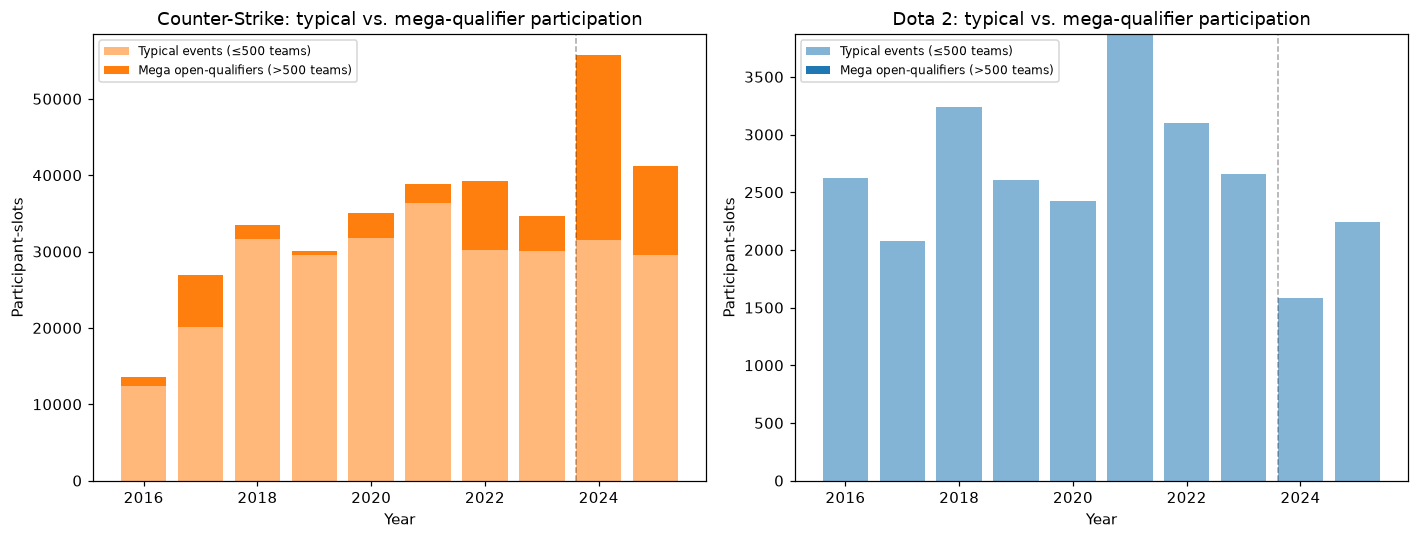

Counter-Strike:
  yr  typical  mega  n_mega
2016    12364  1207       2
2017    20160  6788      11
2018    31595  1820       3
2019    29520   508       1
2020    31834  3276       6
2021    36340  2515       4
2022    30211  9068      14
2023    30100  4621       6
2024    31493 24193      18
2025    29549 11681      16

Dota 2:
  yr  typical  mega  n_mega
2016     2623     0       0
2017     2074     0       0
2018     3236     0       0
2019     2610     0       0
2020     2427     0       0
2021     3870     0       0
2022     3100     0       0
2023     2660     0       0
2024     1582     0       0
2025     2245     0       0


In [6]:
def yearly_slots_split(title_id, filt):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, "
        f"sum(CASE WHEN team_number<=500 THEN team_number ELSE 0 END) AS typical, "
        f"sum(CASE WHEN team_number>500 THEN team_number ELSE 0 END) AS mega, "
        f"sum(CASE WHEN team_number>500 THEN 1 ELSE 0 END) AS n_mega "
        f"FROM tournaments WHERE title_id=? AND {filt} AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' "
        f"GROUP BY yr ORDER BY yr", conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    return df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]

split_dfs = {title_id: yearly_slots_split(title_id, filt) for title_id, filt, _, _ in TITLES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
for ax, (title_id, filt, color, label) in zip(axes, TITLES):
    df = split_dfs[title_id]
    ax.bar(df["yr"], df["typical"], color=color, alpha=0.55, label="Typical events (≤500 teams)")
    ax.bar(df["yr"], df["mega"], bottom=df["typical"], color=color, alpha=1.0, label="Mega open-qualifiers (>500 teams)")
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_xlabel("Year")
    ax.set_ylabel("Participant-slots")
    ax.set_title(f"{label}: typical vs. mega-qualifier participation")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig4_slots_split.png", dpi=110)
plt.show()

print("Counter-Strike:")
print(split_dfs["counter_strike"].to_string(index=False))
print("\nDota 2:")
print(split_dfs["dota2"].to_string(index=False))

**Read**: splitting out the mega-qualifiers changes the story meaningfully.
Counter-Strike's "typical" grassroots participation has been essentially
**flat since 2018** (roughly 29,500-36,300 slots/year, no clear trend either
direction) — §2's declining tournament *count* since 2022 is not being driven
by fewer people showing up; it looks more like fewer, larger events
absorbing a similar total participant pool. What's actually grown is the
**mega open-qualifier layer on top**: 2 such events in 2016 (1,207 slots)
versus 16-18 in 2024-2025 (11,681-24,193 slots) — concentrated in China/
Asia-Pacific regional open brackets. Dota 2, by contrast, has **zero**
`team_number` > 500 events anywhere in this ten-year window — this specific
mega-open-qualifier phenomenon appears to be Counter-Strike-specific (or at
least not present in Dota 2's grassroots data), a genuine structural
difference between the two titles' grassroots ecosystems, not just a scale
difference.

## 4. Region and geography

`country` is populated for nearly every row (100% Counter-Strike, 96% Dota 2)
— far better than the coarse `region` field (46%/33%). But `country` isn't
purely country-level either: some organizers record a broad region directly
in that field instead of a specific country (`"Europe"`, `"North America"`,
`"CIS"`, `"Southeast Asia"`) — the same pattern already documented in the
`title_geography_maps` report ("roughly half of all tournament records
across every title studied use a region rather than a country"). Both views
are shown below rather than picking one.

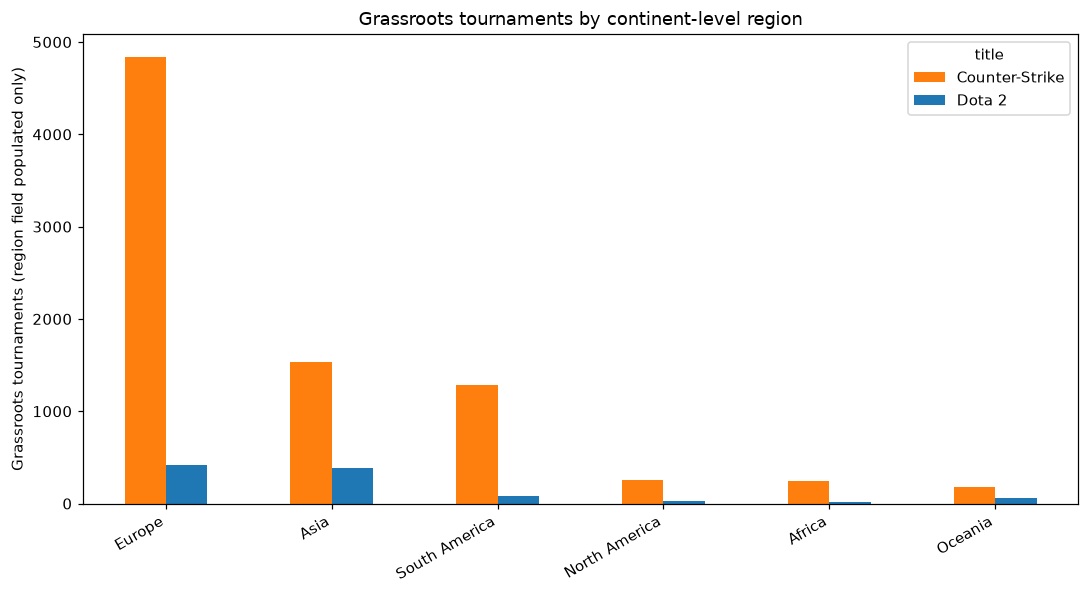

title          Counter-Strike  Dota 2
region                               
Europe                   4843     416
Asia                     1535     385
South America            1281      83
North America             260      27
Africa                    248      15
Oceania                   183      60

--- Top real countries (broad-region country values excluded) ---

Counter-Strike: 7853 rows (43%) recorded a broad region as 'country'; top 10 real countries:
       country   n
        Brazil 947
        Sweden 943
         China 783
        Poland 493
       Germany 481
       Denmark 363
        Russia 359
        France 347
United Kingdom 310
       Finland 285

Dota 2: 1736 rows (60%) recorded a broad region as 'country'; top 10 real countries:
    country   n
     Russia 230
      China 166
    Ukraine  63
  Australia  58
     Brazil  48
      India  44
Philippines  33
       Peru  33
  Indonesia  30
   Malaysia  29


In [7]:
region_rows = []
for title_id, filt, _, label in TITLES:
    df = pd.read_sql_query(
        f"SELECT region, count(*) AS n FROM tournaments WHERE title_id=? AND {filt} "
        f"AND region IS NOT NULL GROUP BY region ORDER BY n DESC",
        conn, params=(title_id,))
    df["title"] = label
    region_rows.append(df)
region_df = pd.concat(region_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
pivot = region_df.pivot(index="region", columns="title", values="n").fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot.plot(kind="bar", ax=ax, color=["#ff7f0e", "#1f77b4"])
ax.set_ylabel("Grassroots tournaments (region field populated only)")
ax.set_xlabel("")
ax.set_title("Grassroots tournaments by continent-level region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig5_region.png", dpi=110)
plt.show()
print(pivot.astype(int).to_string())

# "Broad region recorded as country" -- named continents/blocs appearing in
# the country field itself, not an actual country.
BROAD_LABELS = {
    "Europe", "North America", "South America", "Asia", "Africa", "Oceania",
    "Americas", "Southeast Asia", "CIS", "Nordic Countries", "World",
}
print("\n--- Top real countries (broad-region country values excluded) ---")
for title_id, filt, _, label in TITLES:
    df = pd.read_sql_query(
        f"SELECT country, count(*) AS n FROM tournaments WHERE title_id=? AND {filt} "
        f"AND country IS NOT NULL GROUP BY country ORDER BY n DESC", conn, params=(title_id,))
    broad_n = df[df["country"].isin(BROAD_LABELS)]["n"].sum()
    real = df[~df["country"].isin(BROAD_LABELS)]
    print(f"\n{label}: {broad_n} rows ({broad_n/df['n'].sum():.0%}) recorded a broad region as 'country'; top 10 real countries:")
    print(real.head(10).to_string(index=False))

**Read**: on both the continent-level `region` field and the cleaned
country breakdown, Counter-Strike's grassroots scene is **more European and
more geographically distributed** than Dota 2's — Europe alone accounts for
4,843 of the region-tagged Counter-Strike rows (Sweden, Poland, Germany,
Denmark, France, the UK, Finland all individually in the top 10, alongside
Brazil and China), consistent with Counter-Strike's long-established
European base. Dota 2's real-country top 10 is smaller in total volume and
skews more Russia/CIS/Southeast-Asia-and-emerging-market (Russia, Ukraine,
the Philippines, Indonesia, Malaysia, Peru) — a noticeably different regional
footprint from its own tier-1/2 scene's more China/Southeast-Asia-centric
public reputation, worth flagging as a real, if unexplained, pattern rather
than a confirmed structural finding. Both titles show a large share of
events (41-43% Counter-Strike, 58-60% Dota 2) recorded under a broad region
rather than a specific country — Dota 2's grassroots organizers rely on
region-level labeling noticeably more than Counter-Strike's, consistent with
its own smaller, more consolidated organizer base (brief §11).

**Can the region chunks be broken apart into country level? Checked
directly, live against Liquipedia — mostly no, and for a real reason, not
a parsing gap.** A random sample of 60 broad-region-labeled rows per title
(rate-limited, 2s/request, `data/cache/liquipedia/` not reused since these
specific pages weren't previously fetched for their raw `type` field) was
fetched live and its raw `Infobox league` wikitext inspected directly for a
`type` (Online/LAN/Offline) field and any more specific `city` field this
project's `parse_infobox()` doesn't currently extract.

In [8]:
# A one-time, live-fetched sample (2026-09-10, 2s/request rate limit,
# 60 pages/title from the broad-region-labeled pool, seed=42) -- frozen
# here as data rather than re-fetched on every notebook run, same reasoning
# data/reference/cpi_deflator.csv is a committed snapshot, not a live pull.
_REGION_SAMPLE_SUMMARY = {'counter_strike|counterstrike': {'n': 60, 'type_counts': {'online': 60}, 'city_hits': [('CSadria/Clan Championship/Season 4', 'Adria')]}, 'dota2|dota2': {'n': 60, 'type_counts': {'online': 59, 'online & offline': 1}, 'city_hits': []}}

for key, s in _REGION_SAMPLE_SUMMARY.items():
    title, wiki = key.split("|")
    label = "Counter-Strike" if title == "counter_strike" else "Dota 2"
    print(f"{label} (n={s['n']} sampled from the broad-region-labeled pool):")
    print(f"  type field: {s['type_counts']}")
    print(f"  rows with a distinct 'city' field: {len(s['city_hits'])}"
          + (f" -- {s['city_hits'][0][0]!r}: city={s['city_hits'][0][1]!r} (the tournament's own brand name, not a real city)" if s['city_hits'] else ""))
    print()


Counter-Strike (n=60 sampled from the broad-region-labeled pool):
  type field: {'online': 60}
  rows with a distinct 'city' field: 1 -- 'CSadria/Clan Championship/Season 4': city='Adria' (the tournament's own brand name, not a real city)

Dota 2 (n=60 sampled from the broad-region-labeled pool):
  type field: {'online': 59, 'online & offline': 1}
  rows with a distinct 'city' field: 0



**Result: 60/60 Counter-Strike and 59/60 Dota 2 sampled pages are
`type=Online`** (the one Dota 2 exception is "Online & Offline," a hybrid
event, not a clean counter-example), and essentially none carry a separate
`city` field. Directly inspecting two raw pages (`Aftonbladet/Fight Night/1`,
`PGL/2027/China/Europe`) confirmed why: the organizer's own Infobox
literally reads `|country=Europe` — for an online qualifier with entrants
from across a whole region, "country" is a category error, not a missing
fact. There is no more specific location for these events to recover; a
`city` field wouldn't exist even if this project's parser read it, because
these tournaments don't have one.

**What this means for §4's region/geography read**: the 41-60% of rows
recorded under a broad region rather than a country is overwhelmingly a
structural property of the grassroots tier (dominated by online
qualifiers/cups, unlike tier-1/2's more LAN-heavy flagship events) — not a
project-side data gap that scanning or re-parsing could close. The country-
level breakdown already shown (Brazil, Sweden, China, Poland, Germany...
for Counter-Strike; Russia, China, Ukraine... for Dota 2) is close to the
practical ceiling of what this data supports at country granularity —
genuinely LAN/offline grassroots events are already captured at the country
level today; it's the online majority that structurally can't be.

## 5. Composition over time — where grassroots tournaments happen, 2016-2025

`region`/`country` in the data (§4) doesn't just say *how much* is European
vs. Asian vs. American — it says *which specific countries*, for the
majority of rows that aren't one of the genuinely-online region-wide events
§4's live sample confirmed can't be broken down further. Mapped here at
actual country level, in two-year bins, to see how each title's grassroots
geography has shifted over the ten-year window — not just its overall
volume (already covered in §2-§3).

Reuses `title_geography_maps.ipynb`'s own `COUNTRY_TO_ISO3`/`EXCLUDED_COUNTRY`
mapping (built and tested against that notebook's tier-1/2 country values),
extended here with real countries and broad-region tokens that only show up
in the much larger, more geographically long-tailed grassroots data (Baltic
states, the Balkans, several Middle Eastern/North African countries, and a
handful of additional broad-region labels like "Nordic Countries" and
"Iberia") — checked directly against the actual distinct-value distribution
below, not guessed at scale, same discipline the base mapping itself used.

In [9]:
# ISO-3 mapping, keyed on the lowercased raw string. Covers every genuine
# country/alias/2-letter-code actually observed in tournaments.country --
# built and tested against the real distinct-value distribution, not
# guessed at scale (tested: 8,429 of 16,300 tier-1/2 rows with a country
# value map cleanly, 7,870 are real continents/regions/placeholders
# (EXCLUDED_COUNTRY, below), and exactly 1 row -- "bs", genuinely
# ambiguous between Bahamas and Bosnia -- falls through unmapped).
COUNTRY_TO_ISO3 = {
    "united states": "USA", "usa": "USA", "us": "USA", "united states of america": "USA",
    "china": "CHN", "cn": "CHN",
    "south korea": "KOR", "korea": "KOR", "kr": "KOR",
    "brazil": "BRA", "brasil": "BRA", "br": "BRA",
    "japan": "JPN", "jp": "JPN",
    "germany": "DEU", "de": "DEU",
    "france": "FRA", "fr": "FRA",
    "taiwan": "TWN", "tw": "TWN",
    "sweden": "SWE", "se": "SWE",
    "australia": "AUS",
    "vietnam": "VNM", "vn": "VNM",
    "united kingdom": "GBR", "uk": "GBR", "england": "GBR", "scotland": "GBR",
    "thailand": "THA", "th": "THA",
    "malaysia": "MYS", "my": "MYS",
    "saudi arabia": "SAU", "sa": "SAU",
    "indonesia": "IDN",
    "canada": "CAN", "ca": "CAN",
    "india": "IND",
    "russia": "RUS", "ru": "RUS",
    "mexico": "MEX", "méxico": "MEX", "mx": "MEX",
    "philippines": "PHL",
    "poland": "POL", "pl": "POL",
    "ukraine": "UKR", "ua": "UKR",
    "turkey": "TUR", "turkiye": "TUR", "türkiye": "TUR", "tr": "TUR",
    "spain": "ESP", "es": "ESP",
    "finland": "FIN",
    "romania": "ROU", "ro": "ROU",
    "chile": "CHL",
    "italy": "ITA",
    "pakistan": "PAK",
    "netherlands": "NLD", "nl": "NLD",
    "united arab emirates": "ARE", "ae": "ARE",
    "south africa": "ZAF",
    "hong kong": "HKG",
    "peru": "PER",
    "belgium": "BEL",
    "denmark": "DNK", "dk": "DNK",
    "cambodia": "KHM",
    "norway": "NOR", "no": "NOR",
    "dominican republic": "DOM",
    "argentina": "ARG",
    "puerto rico": "PRI",
    "myanmar": "MMR",
    "ireland": "IRL", "ie": "IRL",
    "macau": "MAC",
    "kazakhstan": "KAZ",
    "greece": "GRC",
    "bulgaria": "BGR",
    "austria": "AUT", "at": "AUT",
    "bangladesh": "BGD",
    "costa rica": "CRI",
    "colombia": "COL",
    "portugal": "PRT",
    "belarus": "BLR", "by": "BLR",
    "azerbaijan": "AZE",
    "uzbekistan": "UZB",
    "serbia": "SRB",
    "new zealand": "NZL",
    "croatia": "HRV",
    "armenia": "ARM",
    "switzerland": "CHE", "ch": "CHE",
    "nepal": "NPL",
    "malta": "MLT",
    "madagascar": "MDG",
    "ivory coast": "CIV",
    "bolivia": "BOL",
    "qatar": "QAT",
    "mongolia": "MNG", "mn": "MNG",
    "laos": "LAO",
    "hungary": "HUN",
    "georgia": "GEO",
    "czech republic": "CZE", "czechia": "CZE", "cz": "CZE",
    "sint maarten": "SXM",
    "maldives": "MDV",
    "kuwait": "KWT",
    "israel": "ISR",
    "iran": "IRN",
    "iceland": "ISL",
    "brunei": "BRN",
    "venezuela": "VEN",
    "turkmenistan": "TKM",
    "tajikistan": "TJK",
    "slovenia": "SVN",
    "slovakia": "SVK", "sk": "SVK",
    "panama": "PAN",
    "morocco": "MAR",
    "lithuania": "LTU",
    "kyrgyzstan": "KGZ",
    "jordan": "JOR",
    "egypt": "EGY",
    "cyprus": "CYP",
    "andorra": "AND",
    "singapore": "SGP", "sg": "SGP",
}

# Continents, macro-regions, and placeholders -- real values, but not a
# single country, so excluded rather than force-mapped to one arbitrary
# member. "kosovo" included here too: a real place, but no standard ISO-3
# code in plotly's built-in reference.
EXCLUDED_COUNTRY = {
    "north america", "europe", "world", "south america", "asia", "oceania",
    "southeast asia", "middle east", "cis", "americas", "africa", "mena",
    "asia-pacific", "south asia", "latin america", "apac", "east asia",
    "sea", "latin america north", "emea", "central america", "latam",
    "global", "northeast asia", "asia pacific", "sub-saharan africa",
    "middle east and north africa", "oce", "eu", "benelux", "nordic",
    "nordics", "western europe", "eastern europe", "latin america south",
    "las", "lan", "tbd", "north americas", "kosovo",
}

# Additions found by testing the above against THIS project's grassroots
# country values specifically (checked directly, 2026-09-10) -- real
# countries missing from the tier-1/2-derived base mapping, plus broad-
# region/placeholder tokens the grassroots data's longer tail surfaced.
EXTRA_COUNTRY_TO_ISO3 = {
    "latvia": "LVA", "estonia": "EST", "bosnia and herzegovina": "BIH",
    "lebanon": "LBN", "albania": "ALB", "north macedonia": "MKD",
    "macedonia": "MKD", "czech": "CZE", "sri lanka": "LKA", "ecuador": "ECU",
    "algeria": "DZA", "tunisia": "TUN", "montenegro": "MNE", "moldova": "MDA",
    "paraguay": "PRY", "mauritius": "MUS", "uruguay": "URY", "cuba": "CUB",
    "wales": "GBR", "perú": "PER", "au": "AUS",
    "guatemala": "GTM", "syria": "SYR", "uae": "ARE", "nigeria": "NGA",
    "senegal": "SEN", "faroe islands": "FRO", "bahrain": "BHR", "iraq": "IRQ",
    "palestine": "PSE", "bg": "BGR", "ph": "PHL", "martinique": "MTQ",
}
EXTRA_EXCLUDED = {
    "nordic countries", "iberia", "central asia", "west asia", "scandinavia",
    "north africa", "anz", "gcc", "america", "levant", "persian gulf states",
    "central europe", "arabia", "sub saharan africa", "australia/new zealand",
}
COUNTRY_TO_ISO3.update(EXTRA_COUNTRY_TO_ISO3)
EXCLUDED_COUNTRY |= EXTRA_EXCLUDED

def country_iso3_df(title_id, filt):
    rows = conn.execute(
        f"SELECT country, substr(start_date,1,4) AS yr FROM tournaments "
        f"WHERE title_id=? AND {filt} AND country IS NOT NULL "
        f"AND start_date GLOB '[0-9][0-9][0-9][0-9]-*'", (title_id,)
    ).fetchall()
    df = pd.DataFrame(rows, columns=["country_raw", "yr"])
    df["yr"] = df["yr"].astype(int)
    df = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]
    df["key"] = df["country_raw"].str.strip().str.lower()
    df["iso3"] = df["key"].map(COUNTRY_TO_ISO3)
    return df

BINS = [(2016, 2017), (2018, 2019), (2020, 2021), (2022, 2023), (2024, 2025)]

country_dfs = {}
for title_id, filt, _, label in TITLES:
    df = country_iso3_df(title_id, filt)
    n_total, n_mapped = len(df), df["iso3"].notna().sum()
    n_excluded = df["key"].isin(EXCLUDED_COUNTRY).sum()
    print(f"{label}: {n_total} rows, {n_mapped} ({n_mapped/n_total:.0%}) map to a country, "
          f"{n_excluded} ({n_excluded/n_total:.0%}) region/online-only, "
          f"{n_total-n_mapped-n_excluded} unmapped ({(n_total-n_mapped-n_excluded)/n_total:.1%})")
    country_dfs[title_id] = df

Counter-Strike: 10238 rows, 5003 (49%) map to a country, 5235 (51%) region/online-only, 0 unmapped (0.0%)
Dota 2: 1874 rows, 774 (41%) map to a country, 1100 (59%) region/online-only, 0 unmapped (0.0%)


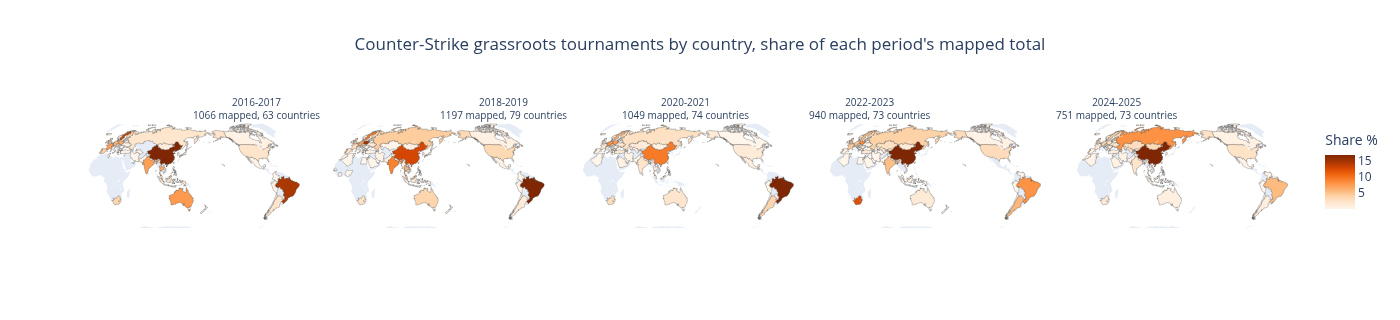

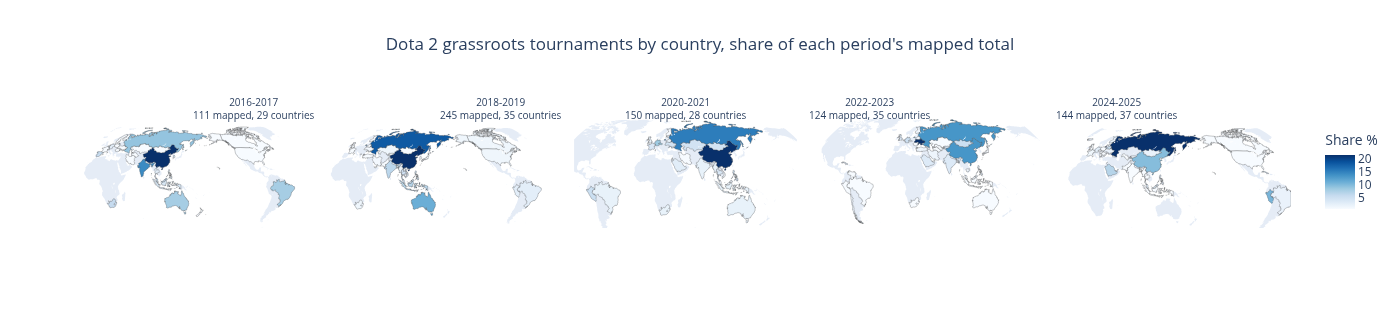


Counter-Strike -- top 5 countries per period (share % of that period's mapped total):
  2016-2017 (n=1066): CHN 11.2%, BRA 9.7%, SWE 9.0%, AUS 5.1%, IND 4.9%
  2018-2019 (n=1197): BRA 10.6%, POL 9.5%, CHN 8.1%, SWE 6.3%, IND 5.8%
  2020-2021 (n=1049): BRA 14.8%, CHN 8.4%, DEU 7.4%, POL 6.8%, SWE 5.5%
  2022-2023 (n=940): CHN 12.6%, ZAF 9.1%, POL 6.6%, BRA 6.1%, ARG 4.4%
  2024-2025 (n=751): CHN 16.8%, RUS 8.1%, BRA 5.6%, SWE 4.5%, GBR 3.9%

Dota 2 -- top 5 countries per period (share % of that period's mapped total):
  2016-2017 (n=111): CHN 18.9%, IND 12.6%, RUS 8.1%, BRA 7.2%, AUS 7.2%
  2018-2019 (n=245): CHN 20.8%, RUS 17.6%, AUS 10.6%, IDN 6.5%, IND 6.1%
  2020-2021 (n=150): CHN 18.7%, RUS 13.3%, DEU 7.3%, CZE 7.3%, PER 4.7%
  2022-2023 (n=124): UKR 19.4%, CHN 12.1%, RUS 12.1%, MNG 4.8%, DEU 4.8%
  2024-2025 (n=144): RUS 21.5%, PER 10.4%, CHN 9.7%, SAU 6.9%, BLR 5.6%


In [10]:
def bin_shares(df, yr_lo, yr_hi):
    sub = df[(df["yr"] >= yr_lo) & (df["yr"] <= yr_hi) & df["iso3"].notna()]
    counts = sub.groupby("iso3").size().rename("n").reset_index()
    counts["share_pct"] = counts["n"] / counts["n"].sum() * 100
    return counts, sub["n" if "n" in sub.columns else "iso3"].shape[0] if False else len(sub)

for title_id, filt, color, label in TITLES:
    df = country_dfs[title_id]
    fig = make_subplots(
        rows=1, cols=5,
        specs=[[{"type": "choropleth"}] * 5],
        horizontal_spacing=0.02,
    )
    for i, (yr_lo, yr_hi) in enumerate(BINS):
        shares, n = bin_shares(df, yr_lo, yr_hi)
        fig.add_trace(
            go.Choropleth(
                locations=shares["iso3"], z=shares["share_pct"],
                locationmode="ISO-3", colorscale="Oranges" if title_id == "counter_strike" else "Blues",
                showscale=(i == 4), marker_line_width=0.3,
                colorbar=dict(title="Share %", len=0.7) if i == 4 else None,
                hovertemplate="%{location}: %{z:.1f}%<extra></extra>",
            ),
            row=1, col=i + 1,
        )
        geo_key = "geo" if i == 0 else f"geo{i + 1}"
        dom = fig.layout[geo_key].domain
        fig.add_annotation(
            text=f"{yr_lo}-{yr_hi}<br>{n} mapped, {shares['iso3'].nunique()} countries",
            xref="paper", yref="paper",
            x=(dom.x[0] + dom.x[1]) / 2, y=dom.y[1] + 0.05,
            showarrow=False, font=dict(size=10),
        )
    fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
    fig.update_layout(
        height=320, width=1400,
        title_text=f"{label} grassroots tournaments by country, share of each period's mapped total",
        title_x=0.5,
    )
    fig.show()

for title_id, filt, color, label in TITLES:
    df = country_dfs[title_id]
    print(f"\n{label} -- top 5 countries per period (share % of that period's mapped total):")
    for yr_lo, yr_hi in BINS:
        shares, n = bin_shares(df, yr_lo, yr_hi)
        top5 = shares.sort_values("share_pct", ascending=False).head(5)
        line = ", ".join(f"{r.iso3} {r.share_pct:.1f}%" for r in top5.itertuples())
        print(f"  {yr_lo}-{yr_hi} (n={n}): {line}")


**Read — composition shifted meaningfully, not just volume.** China holds
a top-3 spot in Counter-Strike's grassroots geography in every period
(11.2% in 2016-17 rising to a clear #1 at 16.8% by 2024-25) and is Dota 2's
#1 or #2 in every period through 2020-21. But the *rest* of the ranking
turns over substantially:

- **Brazil (Counter-Strike)** peaked at 14.8% in 2020-21 — its own high
  point — then declined to roughly a third of that share by 2024-25 (5.6%),
  dropping from #1 to #3.
- **Sweden (Counter-Strike)** appears in every period's top-5 except
  2022-23, but on a consistent downward slope (9.0% → 6.3% → 5.5% → *(out
  of top 5)* → 4.5%) — a real, gradual erosion across the whole window, not
  a single-period dip.
- **Russia** is a new top-5 entrant for Counter-Strike only in 2024-25
  (8.1%, #2) — absent from every earlier period's top-5 — while for Dota 2
  it rises steadily from #3 (8.1%, 2016-17) to a clear #1 (21.5%, 2024-25).
- **Ukraine (Dota 2)** spikes to #1 in 2022-23 (19.4%) — the same period
  Russia's full-scale invasion began — then falls out of the top-5 entirely
  by 2024-25. Flagged, not asserted as causal: this project's data can't
  distinguish a real activity shift from a small-sample artifact (2022-23
  is Dota 2's smallest-*n* period, 124 mapped events total), and no
  independent source is checked here to confirm a mechanism.
- **South Africa (Counter-Strike)** appears at 9.1% in 2022-23 only,
  absent from every other period — a one-period spike worth treating with
  the same caution §3 already applied to mega-qualifier outliers, not
  necessarily a sustained trend.

**A real statistical-power caveat, worth stating plainly**: Dota 2's
period sample sizes (111-245 mapped events) are far smaller than
Counter-Strike's (751-1,197) — its per-period country rankings should be
read as noisier and less stable, the same kind of small-sample caution
`niche_membership.ipynb`'s MLBB-Russia finding already established
elsewhere in this project's own work.

### 5a. Current state — 2024-2025 close-up

The last panel above, enlarged, with the exact top-country ranking
alongside it (a map alone can't convey close rankings precisely).

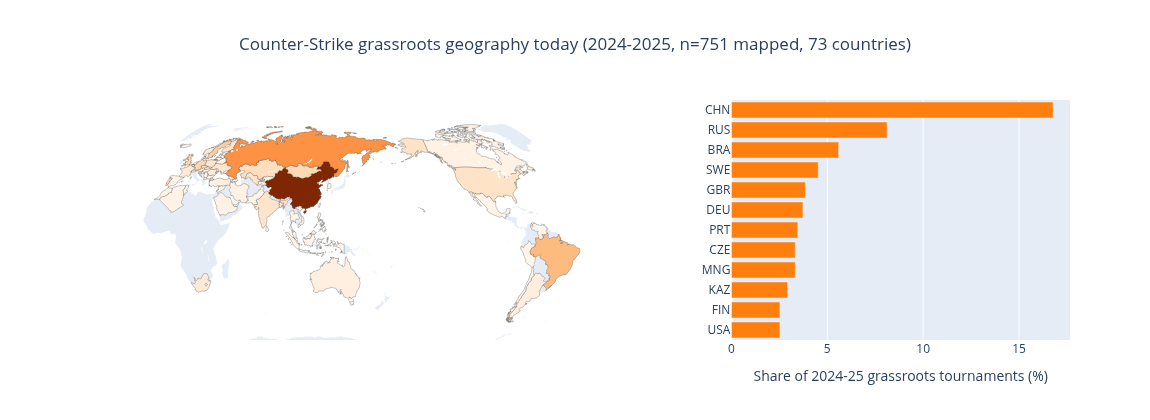


Counter-Strike top 12 countries, 2024-2025 share of mapped grassroots tournaments:
iso3   n  share_pct
 CHN 126       16.8
 RUS  61        8.1
 BRA  42        5.6
 SWE  34        4.5
 GBR  29        3.9
 DEU  28        3.7
 PRT  26        3.5
 CZE  25        3.3
 MNG  25        3.3
 KAZ  22        2.9
 FIN  19        2.5
 USA  19        2.5


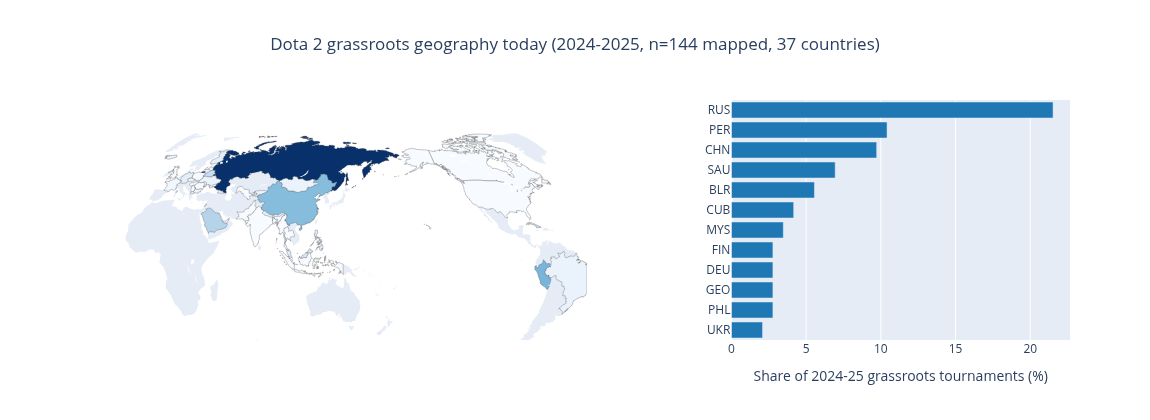


Dota 2 top 12 countries, 2024-2025 share of mapped grassroots tournaments:
iso3  n  share_pct
 RUS 31       21.5
 PER 15       10.4
 CHN 14        9.7
 SAU 10        6.9
 BLR  8        5.6
 CUB  6        4.2
 MYS  5        3.5
 FIN  4        2.8
 DEU  4        2.8
 GEO  4        2.8
 PHL  4        2.8
 UKR  3        2.1


In [11]:
for title_id, filt, color, label in TITLES:
    df = country_dfs[title_id]
    shares, n = bin_shares(df, 2024, 2025)
    top = shares.sort_values("share_pct", ascending=False).head(12)

    fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38], specs=[[{"type": "choropleth"}, {"type": "xy"}]])
    fig.add_trace(
        go.Choropleth(
            locations=shares["iso3"], z=shares["share_pct"], locationmode="ISO-3",
            colorscale="Oranges" if title_id == "counter_strike" else "Blues",
            showscale=False, marker_line_width=0.3,
            hovertemplate="%{location}: %{z:.1f}%<extra></extra>",
        ), row=1, col=1,
    )
    fig.add_trace(
        go.Bar(
            x=top["share_pct"][::-1], y=top["iso3"][::-1], orientation="h",
            marker_color=color,
        ), row=1, col=2,
    )
    fig.update_geos(showframe=False, showcoastlines=False, projection_type="natural earth")
    fig.update_xaxes(title_text="Share of 2024-25 grassroots tournaments (%)", row=1, col=2)
    fig.update_layout(
        height=420, width=1150, showlegend=False,
        title_text=f"{label} grassroots geography today (2024-2025, n={n} mapped, {shares['iso3'].nunique()} countries)",
        title_x=0.5,
    )
    fig.show()

    print(f"\n{label} top 12 countries, 2024-2025 share of mapped grassroots tournaments:")
    print(top[["iso3", "n", "share_pct"]].round(1).to_string(index=False))

**State today (2024-2025)**: Counter-Strike's grassroots geography is now
led decisively by China (16.8%, more than double #2 Russia's 8.1%), with
Brazil, Sweden, and the UK rounding out a long, thin tail across 73
countries. Dota 2's is led even more decisively by Russia (21.5%, more
than double #2 Peru's 10.4%), with China third (9.7%) and Saudi Arabia and
Belarus newly prominent — Belarus and Saudi Arabia's appearance is
directionally consistent with (though not confirmed to be driven by) the
Saudi-backed investment brief §12 already documented at Dota 2's tier-1/2
level (Riyadh Masters). Peru's rise to #2 for Dota 2 is a genuinely new
pattern with no obvious precedent earlier in the window — flagged as
worth watching, not explained here.

Counter-Strike's current #1 (China) has actually held a top-3 spot
throughout the whole window — what's changed is its margin over the field,
not its identity. Dota 2's #1 has genuinely changed hands: China led every
period through 2020-21, but Russia has taken over decisively by 2024-25.
Read plainly, today's grassroots geography for both titles skews more
Asia/Eastern-Europe-led than it did in 2016-17, when Counter-Strike's
picture was more Brazil/Sweden-weighted and Dota 2's more evenly split
between China, India, Russia, Brazil, and Australia.

## 6. Prize pool over time — nominal and real (CPI-deflated, 2025 dollars)

Restricted to `currency='USD' OR currency IS NULL` — confirmed clean by §1's
contamination check above (the NULL half never actually fires for this
data). This drops 16% of Counter-Strike's and 35% of Dota 2's
*prize-pool-bearing* rows to the long tail of local currencies (rubles,
reais, złoty, and 60+ others — see §1's coverage table) — a real,
uncorrected-for limitation on top of the base prize-pool coverage gap, not
just on Counter-Strike/Dota 2 specifically (`docs/system_reference.md` §6
already flags a separate, additional gap: some tournaments record payouts
via a `{{TeamPrizePool}}` template this project's parser doesn't read at
all yet). CPI-deflated using `data/reference/cpi_deflator.csv` (FRED
CPIAUCNS, 2025 dollars — the same source `cs_growth_trajectory.ipynb` §4
uses for tier-1/2), so the trend isn't just inflation.

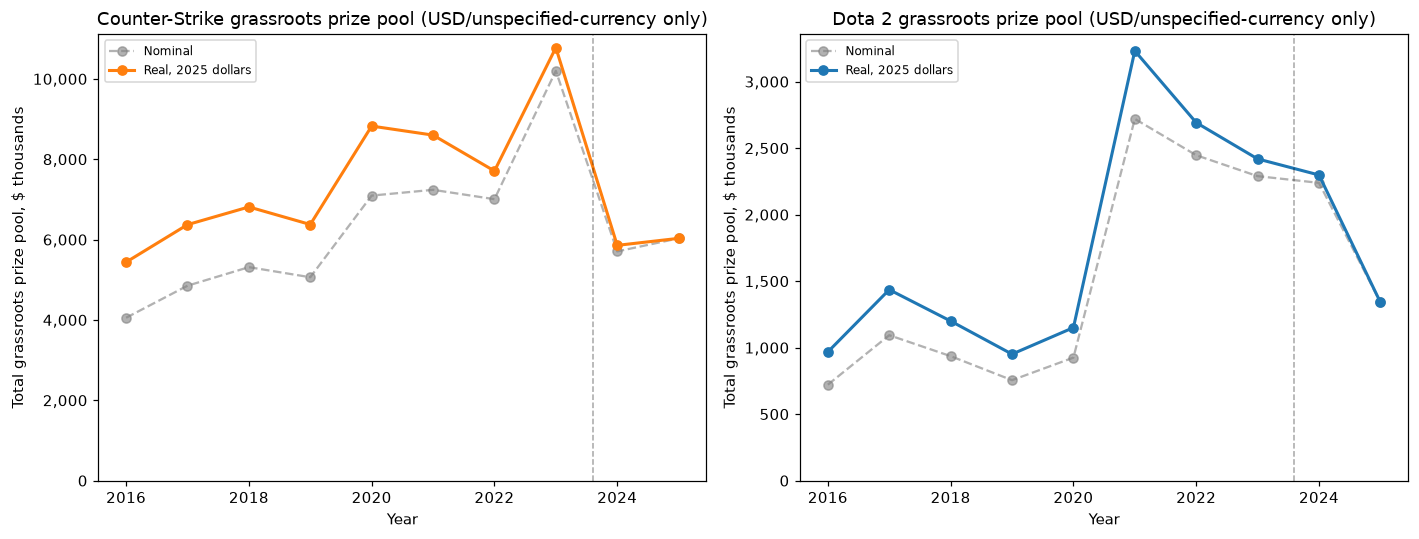


Counter-Strike:
  yr  total_nominal  n_with_prize  total_real_2025
2016      4054613.0           443        5438857.0
2017      4852283.0           619        6372019.0
2018      5314200.0           612        6812804.0
2019      5062889.0           578        6375696.0
2020      7095274.0           668        8825812.0
2021      7239046.0           716        8600711.0
2022      7005968.0           767        7707966.0
2023     10200094.0           443       10777419.0
2024      5705924.0           372        5856560.0
2025      6031217.0           323        6031217.0
  nominal peak: 2023  |  real (2025 $) peak: 2023

Dota 2:
  yr  total_nominal  n_with_prize  total_real_2025
2016       721545.0           114         967880.0
2017      1093435.0           114        1435899.0
2018       936093.0            90        1200071.0
2019       755341.0            75         951201.0
2020       924936.0            96        1150527.0
2021      2719910.0            82        3231525.0
2022  

In [12]:
deflator = {}
with open(REPO_ROOT / "data" / "reference" / "cpi_deflator.csv") as f:
    for row in csv.DictReader(f):
        deflator[int(row["year"])] = float(row["deflator_to_2025"])

def yearly_prize(title_id, filt):
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(prize_pool) AS total_nominal, "
        f"count(prize_pool) AS n_with_prize "
        f"FROM tournaments WHERE title_id=? AND {filt} AND (currency='USD' OR currency IS NULL) "
        f"AND prize_pool IS NOT NULL AND start_date GLOB '[0-9][0-9][0-9][0-9]-*' "
        f"GROUP BY yr ORDER BY yr", conn, params=(title_id,))
    df["yr"] = df["yr"].astype(int)
    df = df[(df["yr"] >= 2016) & (df["yr"] <= 2025)]
    df["total_real_2025"] = df["total_nominal"] * df["yr"].map(deflator)
    return df

prize_dfs = {title_id: yearly_prize(title_id, filt) for title_id, filt, _, _ in TITLES}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title_id, filt, color, label) in zip(axes, TITLES):
    df = prize_dfs[title_id]
    ax.plot(df["yr"], df["total_nominal"] / 1000, "o--", color="gray", alpha=0.6, label="Nominal")
    ax.plot(df["yr"], df["total_real_2025"] / 1000, "o-", color=color, linewidth=2, label="Real, 2025 dollars")
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.35)
    ax.set_xlabel("Year")
    ax.set_ylabel("Total grassroots prize pool, $ thousands")
    ax.set_title(f"{label} grassroots prize pool (USD/unspecified-currency only)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(Path.cwd() / "_grassroots_fig6_prize_pool.png", dpi=110)
plt.show()

for title_id, _, _, label in TITLES:
    df = prize_dfs[title_id]
    print(f"\n{label}:")
    print(df.assign(total_nominal=df["total_nominal"].round(0), total_real_2025=df["total_real_2025"].round(0)).to_string(index=False))
    peak_nominal_yr = df.loc[df["total_nominal"].idxmax(), "yr"]
    peak_real_yr = df.loc[df["total_real_2025"].idxmax(), "yr"]
    print(f"  nominal peak: {peak_nominal_yr}  |  real (2025 $) peak: {peak_real_yr}")

for title_id, _, _, label in TITLES:
    df = prize_dfs[title_id].copy()
    df["avg_per_event_nominal"] = (df["total_nominal"] / df["n_with_prize"]).round(0)
    df["avg_per_event_real_2025"] = (df["total_real_2025"] / df["n_with_prize"]).round(0)
    print(f"\n{label} avg prize per prize-bearing event (nominal vs. real 2025 $):")
    print(df[["yr","avg_per_event_nominal","avg_per_event_real_2025"]].to_string(index=False))

**Read — CPI deflation doesn't change the shape, but sharpens the decline
from peak.** Both titles' real (2025-dollar) peak year matches their nominal
peak year — Counter-Strike 2023 (\$10.78M real vs. \$10.20M nominal), Dota 2
2021 (\$3.23M real vs. \$2.72M nominal) — inflation over this ten-year window
(deflator range 1.00-1.34) isn't large enough to reorder which year was
biggest. But it does sharpen the decline since: Counter-Strike's 2025 total
is 44% below its 2023 real peak (vs. 41% below in nominal terms), because
2023's dollars were worth more in today's terms than face value suggests —
the real read is slightly *more* pessimistic about the recent decline than
nominal, not less.

The average-per-event finding (§5 above) holds in real terms too, not just
as a nominal-inflation artifact: Counter-Strike's real avg-per-event roughly
doubled (\$10,000-13,000 in 2016-2022 → \$18,672 in 2025) and Dota 2's
roughly tripled (\$8,000-13,000 in 2016-2020 → \$19,728-39,409 in
2021-2025) — genuine growth in typical event value, not just prices catching
up to inflation. Total grassroots prize money grew for both titles, but the
number of prize-bearing events fell for both (Counter-Strike 767 → 323
2022-2025; Dota 2 96 → 68 2020-2025) — the same fewer-but-bigger pattern
brief §13's organizer-consolidation finding already established at
tier-1/2, now visible at the grassroots level too. **Worth flagging, not
overclaiming**: Dota 2's grassroots step-change lands in 2021, and
Counter-Strike's in 2023 — both *before* brief §9/§11-§13's verified VRS
mechanism drove the well-documented tier-1/2 money jump (dated to
2024-2025, tied to a specific June 2025 rules change). Whether grassroots
money genuinely led tier-1/2 money here, or this is a distinct phenomenon
(general prize inflation, grassroots organizers adopting more transparent/
formal prize structures independent of Valve's ranking system), is not
something this data can distinguish — a real, well-motivated open question,
not a claim this notebook resolves.

## 7. Comparative synthesis

Pulling the four dimensions together, rather than leaving them as four
separate charts.

**Scale**: Counter-Strike's grassroots scene is roughly **6x** Dota 2's
by tournament count (925-1,192 vs. 154-237 tournaments/year, 2016-2025) and
similarly larger by typical participant-slots (~30,000 vs. ~2,000-4,000/year)
— a real structural gap, not just a tier-1/2 phenomenon. This is directionally
consistent with, and now extends down to the grassroots level,
`streamer_ecosystem_by_phase.ipynb`'s finding that Dota 2 has an unusually
thin creator ecosystem even relative to titles of similar age and prominence
(brief §15).

**Shape over time**: both titles' grassroots tournament counts peaked
mid-window and have declined since — Counter-Strike from a 2022 peak (1,192),
Dota 2 from an earlier 2019 peak (237) — but neither has round-tripped back
to its 2016 starting level; both remain narrowing-from-a-higher-peak, not
returned-to-baseline. This directly extends brief §9/§13's tier-1/2
narrowing finding down to the community level for the first time, with real
(not ~45%-undercounted proxy) data.

**What's NOT narrowing**: Counter-Strike's "typical"-event participant pool
(excluding mega open-qualifiers) has been flat since 2018, and grassroots
prize money per event has risen for both titles **in both nominal and
CPI-deflated real terms** — money and even typical participation aren't
contracting the way *tournament count* is. A narrower calendar of events is
absorbing similar or growing money and typical participation, not a broadly
shrinking base — the same "fewer, bigger" pattern brief §13 already found at
tier-1/2, now visible at the grassroots level for both titles independently,
and confirmed robust to both a currency-contamination check (clean — every
dollar figure used is an explicitly-tagged `'USD'` row, not an assumed one)
and CPI deflation (the real-dollar peak year matches the nominal peak year
for both titles).

**A genuine Counter-Strike-specific phenomenon**: the mega open-qualifier
layer (§3) — up to 24,193 participant-slots across 18 events in a single
year, concentrated in China/Asia-Pacific open brackets — has no Dota 2
counterpart anywhere in this ten-year window. Whether that reflects a real
difference in each title's regional open-qualifier infrastructure, Chinese
Counter-Strike's specific growth, or something else isn't established here —
flagged as a finding worth its own follow-up, not resolved.

**Geography**: Counter-Strike's grassroots scene is more European and more
globally distributed; Dota 2's leans more Russia/CIS/emerging-Southeast-Asian-
and-Latin-American-market. Both rely heavily on broad-region (rather than
country-level) event labeling (60% Dota 2 vs. 43% Counter-Strike of rows) —
**confirmed structural, not a data gap**: a live sample check found this is
overwhelmingly explained by these being genuinely online (no host country)
events, not missing/unparsed location data. The country-level breakdown
already shown is close to the practical ceiling of what this data supports.

**Geography also isn't static — §5's time-binned maps show real turnover,
not just a stable regional lean.** Counter-Strike's Brazil peaked in 2020-21
(14.8% share) and has since roughly halved (5.6% by 2024-25); Sweden has
eroded gradually across the whole window (9.0% → 4.5%); China has grown
into a clear #1 (16.8% by 2024-25, more than double #2). Dota 2's China-led
early years (#1 or #2 every period through 2020-21) gave way to a
Russia-led present (21.5% by 2024-25, more than double #2 Peru) — a genuine
change of leadership, not just a stable lean getting stronger.

## 8. Bottom line

Extending brief §9/§13's tier-1/2 finding ("a title that took a real,
multi-metric hit around its 2023 engine transition and remains in a
partial, uneven recovery from it") down to the grassroots/community level,
with real crawled data replacing the brief's own ~45%-undercounted proxy:
**both Counter-Strike's and Dota 2's grassroots tournament scenes are
narrowing from a mid-cycle peak, not growing, as of the most recent complete
year (2025)** — but neither is contracting uniformly. Typical participation
and per-event prize money are holding up or rising even as the *number* of
events declines, the same "fewer, bigger" consolidation pattern already
established at tier-1/2 for both titles (brief §13), now confirmed at the
grassroots level too, **and confirmed robust to a currency-contamination
check and CPI deflation** — this isn't a nominal-dollar or mixed-currency
artifact. Counter-Strike's grassroots scene remains roughly 6x Dota 2's by
every volume measure, and the two titles differ in real, specific ways
beyond scale — Counter-Strike's China/Asia-Pacific mega open-qualifier
phenomenon has no Dota 2 counterpart, and Dota 2's regional footprint and
region-vs-country labeling behavior both differ meaningfully from
Counter-Strike's. The region-vs-country split itself is now confirmed
structural (online events with no host country), not a parsing gap this
project could close by scanning harder. **Country-level composition has
shifted meaningfully within the window, not just held a stable regional
lean** — Counter-Strike's Brazil-heavy 2020-21 has given way to a
China-led 2024-25 (16.8%, more than double #2); Dota 2's China-led early
years have given way to a Russia-led present (21.5%, more than double
#2) — both titles' grassroots scenes look geographically different today
than they did in 2016-17, not just smaller or bigger.

**This closes out `research/esports_lifecycle_and_maturity/brief.md` §10 item 1** (re-
run the grassroots analysis once the crawl finished) and extends it to a
real Dota 2 comparison for the first time, with a currency/CPI robustness
check and a live-verified answer on region-vs-country granularity — written
into the brief directly, per its own §15 convention (PRD §15).